In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier,)
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix,classification_report,)
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
import pickle as pkl


In [3]:
data=pd.read_csv('BMW sales data (2010-2024) (1).csv')

In [4]:
data

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


In [5]:
data.drop(['Sales_Volume'],axis=1,inplace=True)

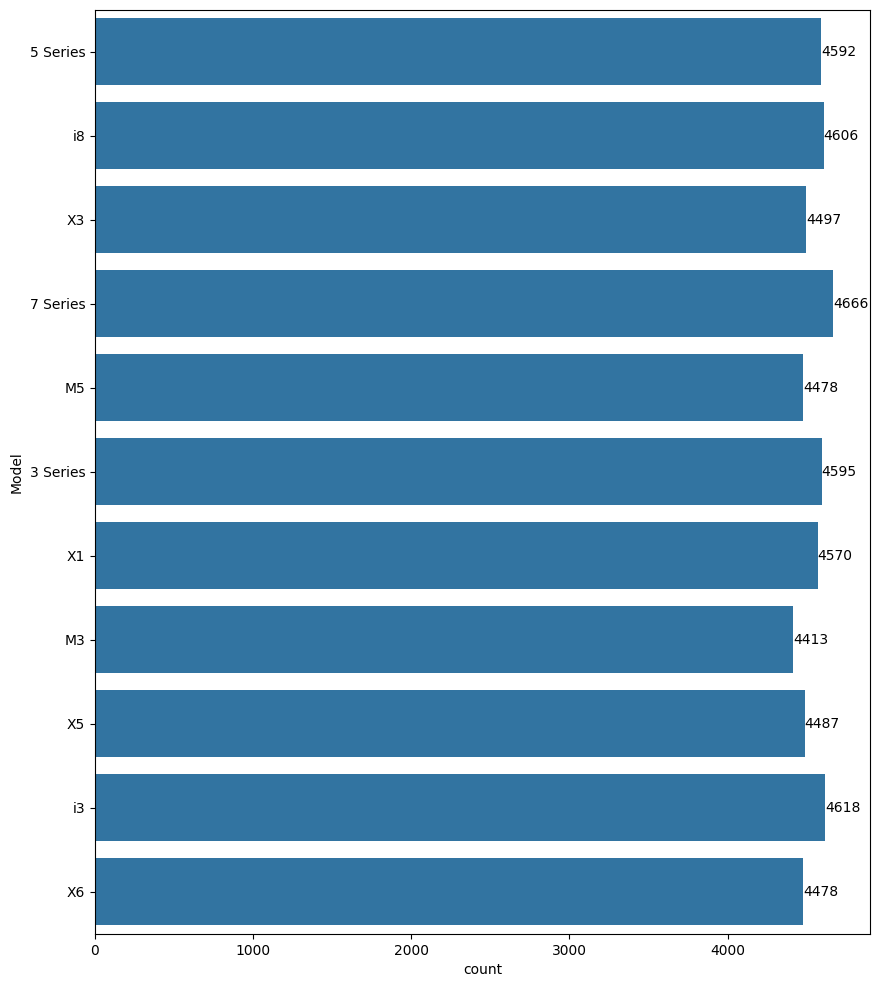

In [6]:
plt.figure(figsize=(10,12))
for  i in sns.countplot(data['Model']).containers:
    plt.bar_label(i)

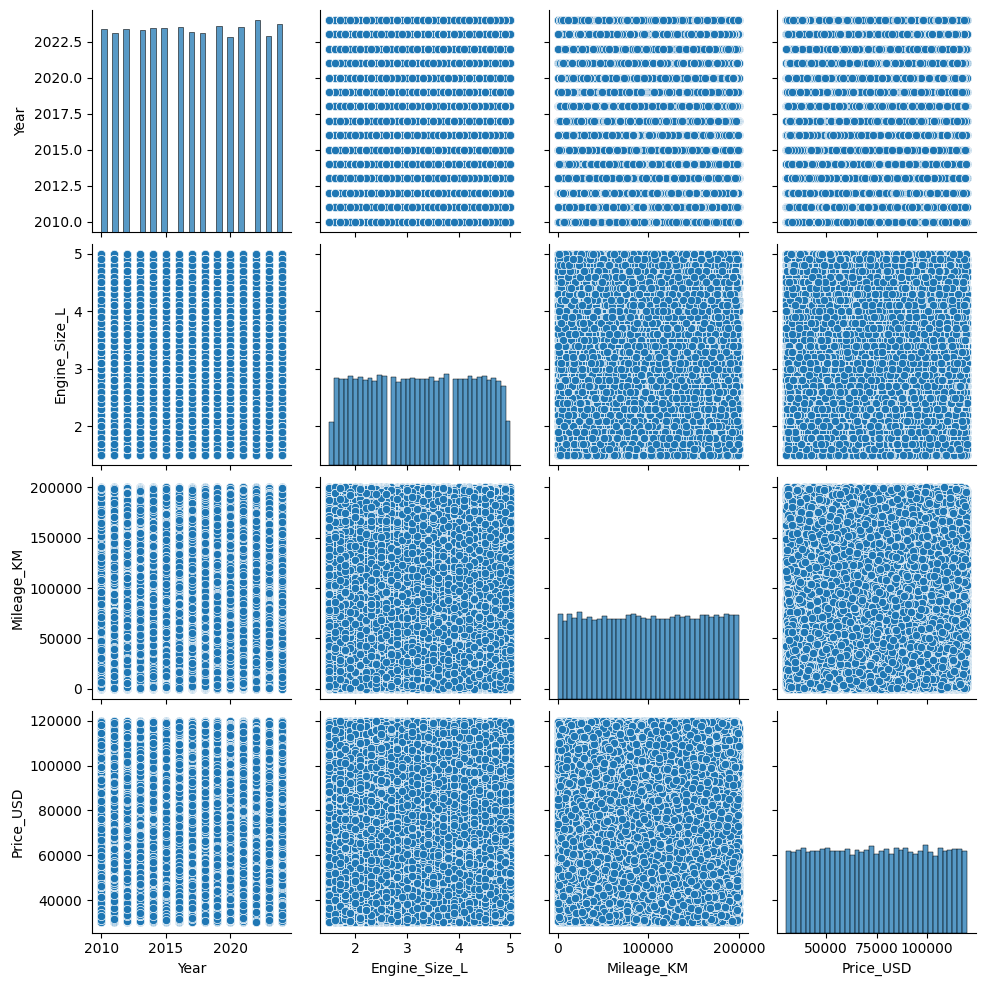

In [7]:
sns.pairplot(data)

In [8]:
x_train,x_test,Y_train,y_test=train_test_split(data.drop(['Sales_Classification'],axis=1),
                                               data[['Sales_Classification']],train_size=0.7,random_state=1)

In [9]:
Y_train.value_counts()

Sales_Classification
Low                     24305
High                    10695
Name: count, dtype: int64

In [10]:
sacaler=StandardScaler()
temp=sacaler.fit_transform(x_train.select_dtypes(include=[float,int]))

In [11]:
x_train_scaled=pd.DataFrame(temp,columns=sacaler.get_feature_names_out(),index=x_train.index)

In [12]:
x_train_scaled


,Year,Engine_Size_L,Mileage_KM,Price_USD
8950,-0.929435,0.752599,1.238046,-0.024279
38421,0.455901,-1.532580,-0.628835,0.969516
19363,0.917680,-1.035802,-1.024702,-0.707404
30157,1.148569,-0.240957,-1.604874,-0.454557
14294,1.148569,-1.433224,-1.688738,-0.287366
...,...,...,...,...
43723,0.225012,-0.936446,-1.175095,-1.072970
32511,0.686790,1.249377,-1.656174,-1.633868
5192,1.610348,-1.433224,1.183479,-1.726145
12172,-1.160325,0.156465,0.305184,0.014757


In [13]:
ohe=OneHotEncoder()
temp=ohe.fit_transform(x_train.select_dtypes(include=[object])).toarray()


In [14]:
x_train_encoded=pd.DataFrame(temp,columns=ohe.get_feature_names_out(),index=x_train.index)


In [15]:
x_train_encoded

,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,Model_X5,Model_X6,Model_i3,...,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
8950,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
38421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
19363,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
30157,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
14294,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
32511,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5192,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
12172,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [16]:
x_train_final=pd.concat([x_train_encoded,x_train_scaled],axis=1)

In [17]:
x_train_final

,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,Model_X5,Model_X6,Model_i3,...,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Year,Engine_Size_L,Mileage_KM,Price_USD
8950,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,-0.929435,0.752599,1.238046,-0.024279
38421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.455901,-1.532580,-0.628835,0.969516
19363,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.917680,-1.035802,-1.024702,-0.707404
30157,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.148569,-0.240957,-1.604874,-0.454557
14294,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.148569,-1.433224,-1.688738,-0.287366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.225012,-0.936446,-1.175095,-1.072970
32511,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.686790,1.249377,-1.656174,-1.633868
5192,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.610348,-1.433224,1.183479,-1.726145
12172,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,-1.160325,0.156465,0.305184,0.014757


In [18]:
temp=sacaler.transform(x_test.select_dtypes(include=[float,int]))
x_test_scaled=pd.DataFrame(temp,columns=sacaler.get_feature_names_out(),index=x_test.index)

In [19]:

temp=ohe.fit_transform(x_test.select_dtypes(include=[object])).toarray()
x_test_encoded=pd.DataFrame(temp,columns=ohe.get_feature_names_out(),index=x_test.index)

In [20]:
x_test_encoded

,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,Model_X5,Model_X6,Model_i3,...,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
26247,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
35067,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
34590,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
16668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
12196,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14876,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
42772,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
37248,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6246,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [21]:
Y_train_encoded=Y_train['Sales_Classification'].map({"Low":0,"High":1})

In [22]:
Y_train_encoded

8950     0
38421    0
19363    1
30157    0
14294    0
        ..
43723    0
32511    0
5192     0
12172    0
33003    1
Name: Sales_Classification, Length: 35000, dtype: int64

In [23]:
Y_test_encoded=y_test['Sales_Classification'].map({"Low":0,"High":1})

In [24]:
Y_test_encoded

26247    1
35067    0
34590    0
16668    0
12196    1
        ..
14876    0
42772    0
37248    0
6246     1
11103    0
Name: Sales_Classification, Length: 15000, dtype: int64

In [25]:
x_test_final=pd.concat([x_test_encoded,x_test_scaled],axis=1)

[Text(0, 0, '24305'), Text(0, 0, '10695')]

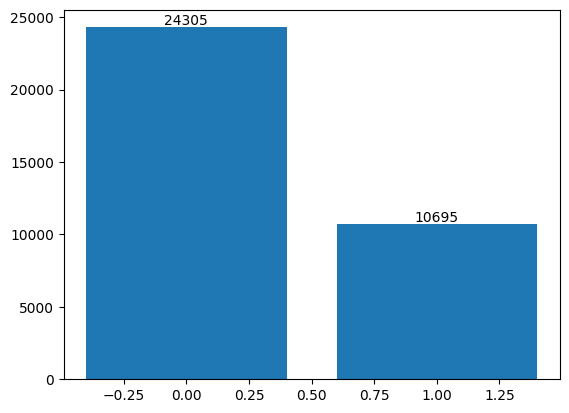

In [26]:
plt.bar_label(plt.bar(Y_train_encoded.value_counts().index,Y_train_encoded.value_counts().values))

In [27]:
models={
    'AdaBoostClassifier':AdaBoostClassifier(),
    'GradientBoostingClassifier':GradientBoostingClassifier(),
    'XGBClassifier':XGBClassifier(),
    'RandomForestClassifier':RandomForestClassifier(n_jobs=-1,class_weight='balanced'),
    'DecisionTreeClassifier':DecisionTreeClassifier(class_weight='balanced')
}


In [28]:
# for name,model in models.items():
#     print(name)
#     model.fit(x_train_final,Y_train_encoded)
#     y_pred=model.predict(x_test_final)

#     print(confusion_matrix(y_pred=y_pred,y_true=Y_test_encoded))
#     print(classification_report(y_pred=y_pred,y_true=Y_test_encoded))

In [29]:

params=dict(criterion=['gini', 'entropy',],
            splitter=['best','random'],
            max_depth=[5,10,15,20,None],
            max_features=[None, 'sqrt', 'log2'],
            class_weight=['balanced',None],
            min_samples_split=[2,3,10,15,20],
            min_samples_leaf=[1,2,4,8],
           
            
            
            )

In [30]:
# grid=RandomizedSearchCV(estimator=DecisionTreeClassifier(),param_distributions=params,n_jobs=-1,cv=StratifiedKFold(),scoring='f1')

In [31]:
grid.fit(x_train_final,Y_train_encoded)

NameError: name 'grid' is not defined

In [ ]:
# y_pred_c=grid.predict(x_test_final)


In [ ]:
# print(confusion_matrix(y_pred=y_pred_c,y_true=Y_test_encoded))
# print(classification_report(y_pred=y_pred_c,y_true=Y_test_encoded))

[[5346 5103]
 [2376 2175]]
              precision    recall  f1-score   support

           0       0.69      0.51      0.59     10449
           1       0.30      0.48      0.37      4551

    accuracy                           0.50     15000
   macro avg       0.50      0.49      0.48     15000
weighted avg       0.57      0.50      0.52     15000



In [ ]:
pkl.dump(grid,open('Model.pkl','wb'))

In [ ]:
pkl.load(open('Model.pkl','rb'))

,estimator,DecisionTreeClassifier()
,param_distributions,"{'class_weight': ['balanced', None], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'max_features': [None, 'sqrt', ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [ ]:
pkl.dump(sacaler,open('scaler.pkl','wb'))
pkl.dump(ohe,open('ohe.pkl','wb'))

In [ ]:
x_train_final


,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,Model_X5,Model_X6,Model_i3,...,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Year,Engine_Size_L,Mileage_KM,Price_USD
8950,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,-0.929435,0.752599,1.238046,-0.024279
38421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.455901,-1.532580,-0.628835,0.969516
19363,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.917680,-1.035802,-1.024702,-0.707404
30157,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.148569,-0.240957,-1.604874,-0.454557
14294,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.148569,-1.433224,-1.688738,-0.287366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.225012,-0.936446,-1.175095,-1.072970
32511,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.686790,1.249377,-1.656174,-1.633868
5192,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.610348,-1.433224,1.183479,-1.726145
12172,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,-1.160325,0.156465,0.305184,0.014757


In [ ]:
ohe.feature_names_in_

array(['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission'],
      dtype=object)

In [ ]:
sacaler.feature_names_in_

array(['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD'], dtype=object)

In [33]:
data['Model'].value_counts().index

Index(['7 Series', 'i3', 'i8', '3 Series', '5 Series', 'X1', 'X3', 'X5', 'M5',
       'X6', 'M3'],
      dtype='object', name='Model')